In [ ]:
"""
EDA - df1.csv: Air transport, passengers carried (World Bank)
==============================================================
Dataset: World Bank IS.AIR.PSGR
Copertura: ~266 paesi/regioni, anni 1960–2023 (dati utili dal ~1970)
 
Struttura dell'EDA:
  0. Setup & caricamento
  1. Pulizia e reshape (wide → long)
  2. Overview generale
  3. Copertura temporale e valori nulli
  4. Distribuzione globale dei passeggeri
  5. Top paesi / regioni
  6. Trend globale (1970–2023)
  7. Impatto COVID-19
  8. Analisi per macro-regioni
  9. Crescita relativa e ranking dinamico
  10. Correlogram / heatmap anni
"""

In [1]:
# =============================================================================
# 0. SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")
 
# Stile globale
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#F7F7F5",
    "axes.facecolor":   "#F7F7F5",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#DDDDDD",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "axes.titlesize":   12,
    "axes.labelsize":   10,
})
 
FILE = "df1.csv"   # ← modifica il percorso se necessario

In [2]:

# =============================================================================
# 1. CARICAMENTO & PULIZIA
# =============================================================================
df_raw = pd.read_csv(FILE)
 
# Rimuovi colonna vuota
df_raw.drop(columns=["Unnamed: 70"], errors="ignore", inplace=True)
 
# Anni disponibili
year_cols = [c for c in df_raw.columns if c.isdigit()]
years     = [int(y) for y in year_cols]
 
print(f"Shape raw:  {df_raw.shape}")
print(f"Anni:       {min(years)} – {max(years)}")
print(f"Paesi/reg:  {df_raw['Country Name'].nunique()}")
 
# ── Reshape wide → long ──────────────────────────────────────────────────────
df_long = df_raw.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passengers"
)
df_long["Year"]       = df_long["Year"].astype(int)
df_long["Passengers"] = pd.to_numeric(df_long["Passengers"], errors="coerce")
 
# Rimuovi 2024/2025 (tutti NaN)
df_long = df_long[df_long["Year"] <= 2023]
 
# Separa paesi singoli da aggregati regionali
# I codici regionali World Bank hanno 3 lettere ma non sono codici ISO standard
REGIONAL_CODES = {
    "WLD","EAS","ECS","LCN","MEA","NAC","SAS","SSF","EAP","ECA","LAC","MNA",
    "SSA","HIC","MIC","LMC","UMC","LIC","IBRD","IDA","OED","AFE","AFW","ARB",
    "CEB","CSS","EAR","EMU","EUU","FCS","HPC","IBD","IBT","IDX","IDB","INX",
    "LAC","LDC","LTE","MNA","NAF","OED","OSS","PRE","PSS","PST","SAS","SST",
    "TEA","TEC","TLA","TMN","TSA","TSS","UMC","WLD","XZN"
}
df_countries = df_long[~df_long["Country Code"].isin(REGIONAL_CODES)].copy()
df_regions   = df_long[ df_long["Country Code"].isin(REGIONAL_CODES)].copy()
 
print(f"\nRighe totali (long):  {len(df_long):,}")
print(f"Paesi singoli:        {df_countries['Country Name'].nunique()}")
print(f"Aggregati regionali:  {df_regions['Country Name'].nunique()}")

Shape raw:  (266, 70)
Anni:       1960 – 2025
Paesi/reg:  266

Righe totali (long):  17,024
Paesi singoli:        218
Aggregati regionali:  48


In [3]:
# =============================================================================
# 2. OVERVIEW
# =============================================================================
print("\n" + "="*60)
print("OVERVIEW STATISTICA (dati non-NaN, anno >= 1970)")
print("="*60)
subset = df_long[(df_long["Year"] >= 1970) & df_long["Passengers"].notna()]
print(subset["Passengers"].describe().apply(lambda x: f"{x:,.0f}"))


OVERVIEW STATISTICA (dati non-NaN, anno >= 1970)
count           10,300
mean        68,762,734
std        261,633,692
min                  0
25%            347,108
50%          1,945,019
75%         16,524,503
max      4,455,690,101
Name: Passengers, dtype: str


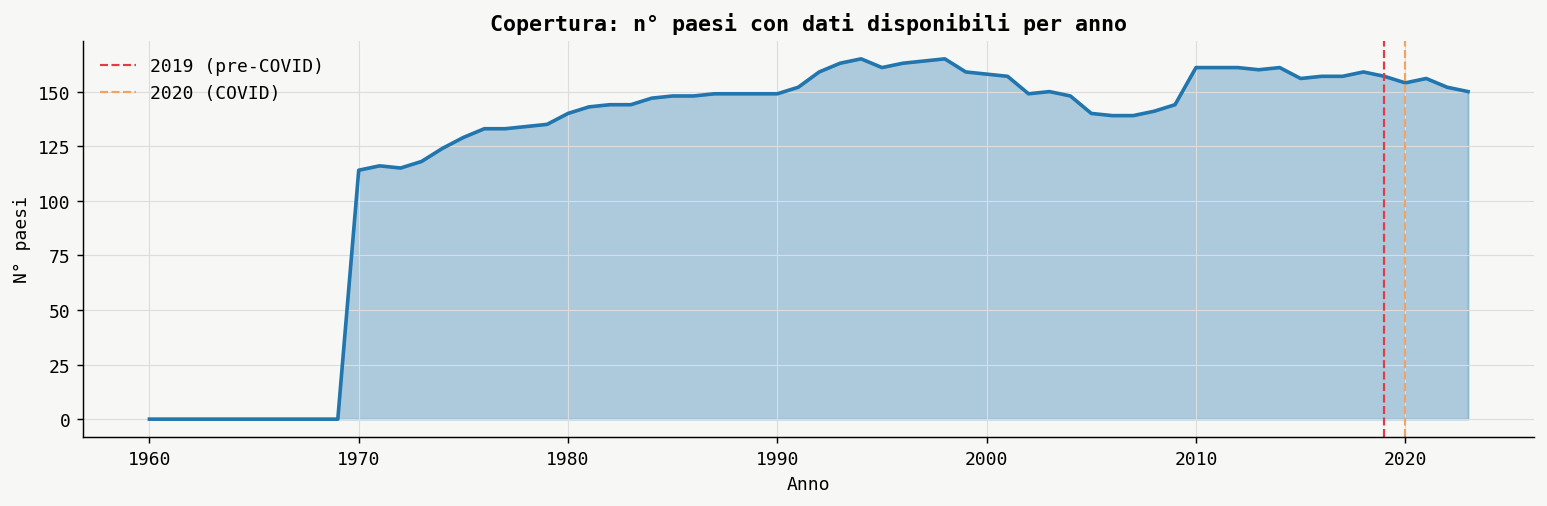

[Salvato] eda_01_coverage.png


In [4]:
# =============================================================================
# 3. COPERTURA TEMPORALE (quanti paesi hanno dati per anno)
# =============================================================================
coverage = (
    df_countries.groupby("Year")["Passengers"]
    .apply(lambda s: s.notna().sum())
    .reset_index(name="n_countries")
)
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(coverage["Year"], coverage["n_countries"], alpha=0.35, color="#2176AE")
ax.plot(coverage["Year"], coverage["n_countries"], color="#2176AE", lw=2)
ax.axvline(2019, color="#E63946", ls="--", lw=1.2, label="2019 (pre-COVID)")
ax.axvline(2020, color="#F4A261", ls="--", lw=1.2, label="2020 (COVID)")
ax.set_title("Copertura: n° paesi con dati disponibili per anno", fontweight="bold")
ax.set_xlabel("Anno"); ax.set_ylabel("N° paesi")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_01_coverage.png")
plt.show()
print("[Salvato] eda_01_coverage.png")

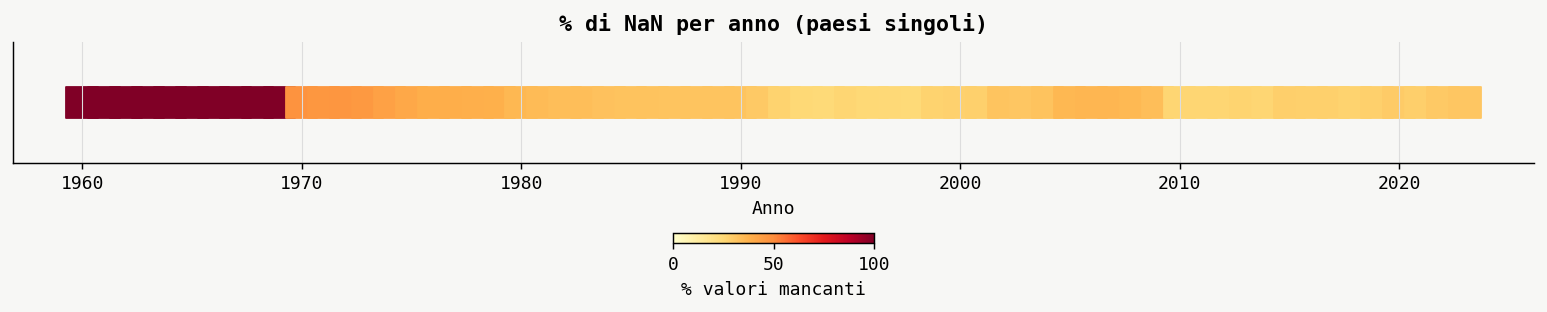

[Salvato] eda_02_nullity.png


In [5]:
# =============================================================================
# 4. HEATMAP NULLITÀ per anno
# =============================================================================
null_pct = (
    df_countries.groupby("Year")["Passengers"]
    .apply(lambda s: s.isna().mean() * 100)
    .reset_index(name="null_pct")
)
 
fig, ax = plt.subplots(figsize=(12, 2.5))
sc = ax.scatter(null_pct["Year"], [1]*len(null_pct),
                c=null_pct["null_pct"], cmap="YlOrRd",
                s=300, marker="s", vmin=0, vmax=100)
plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.05,
             pad=0.35, label="% valori mancanti")
ax.set_yticks([])
ax.set_title("% di NaN per anno (paesi singoli)", fontweight="bold")
ax.set_xlabel("Anno")
plt.tight_layout()
plt.savefig("eda_02_nullity.png")
plt.show()
print("[Salvato] eda_02_nullity.png")

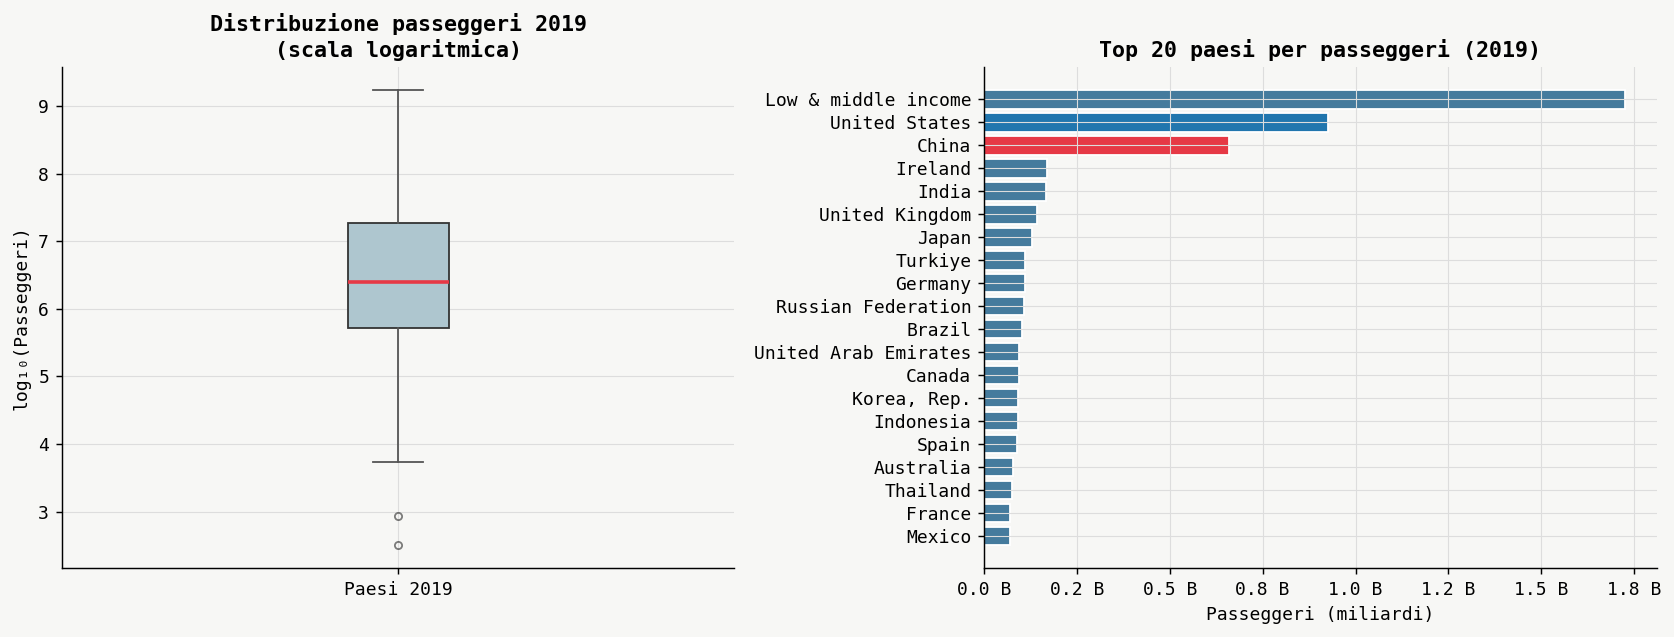

[Salvato] eda_03_dist_2019.png


In [6]:
# =============================================================================
# 5. DISTRIBUZIONE globale 2019 (boxplot + stripplot)
# =============================================================================
data_2019 = df_countries[
    (df_countries["Year"] == 2019) & df_countries["Passengers"].notna()
].copy()
data_2019["log_pax"] = np.log10(data_2019["Passengers"])
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Boxplot
axes[0].boxplot(data_2019["log_pax"].dropna(), vert=True,
                patch_artist=True,
                boxprops=dict(facecolor="#AEC6CF", color="#333"),
                medianprops=dict(color="#E63946", lw=2),
                whiskerprops=dict(color="#555"),
                capprops=dict(color="#555"),
                flierprops=dict(marker="o", color="#2176AE", alpha=0.5, ms=4))
axes[0].set_xticks([1]); axes[0].set_xticklabels(["Paesi 2019"])
axes[0].set_ylabel("log₁₀(Passeggeri)")
axes[0].set_title("Distribuzione passeggeri 2019\n(scala logaritmica)", fontweight="bold")
 
# Top 20 barchart
top20 = data_2019.nlargest(20, "Passengers")
colors = ["#E63946" if c == "CHN" else "#2176AE" if c == "USA"
          else "#457B9D" for c in top20["Country Code"]]
axes[1].barh(top20["Country Name"], top20["Passengers"] / 1e9,
             color=colors, edgecolor="white")
axes[1].set_xlabel("Passeggeri (miliardi)")
axes[1].set_title("Top 20 paesi per passeggeri (2019)", fontweight="bold")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f B"))
 
plt.tight_layout()
plt.savefig("eda_03_dist_2019.png")
plt.show()
print("[Salvato] eda_03_dist_2019.png")
 

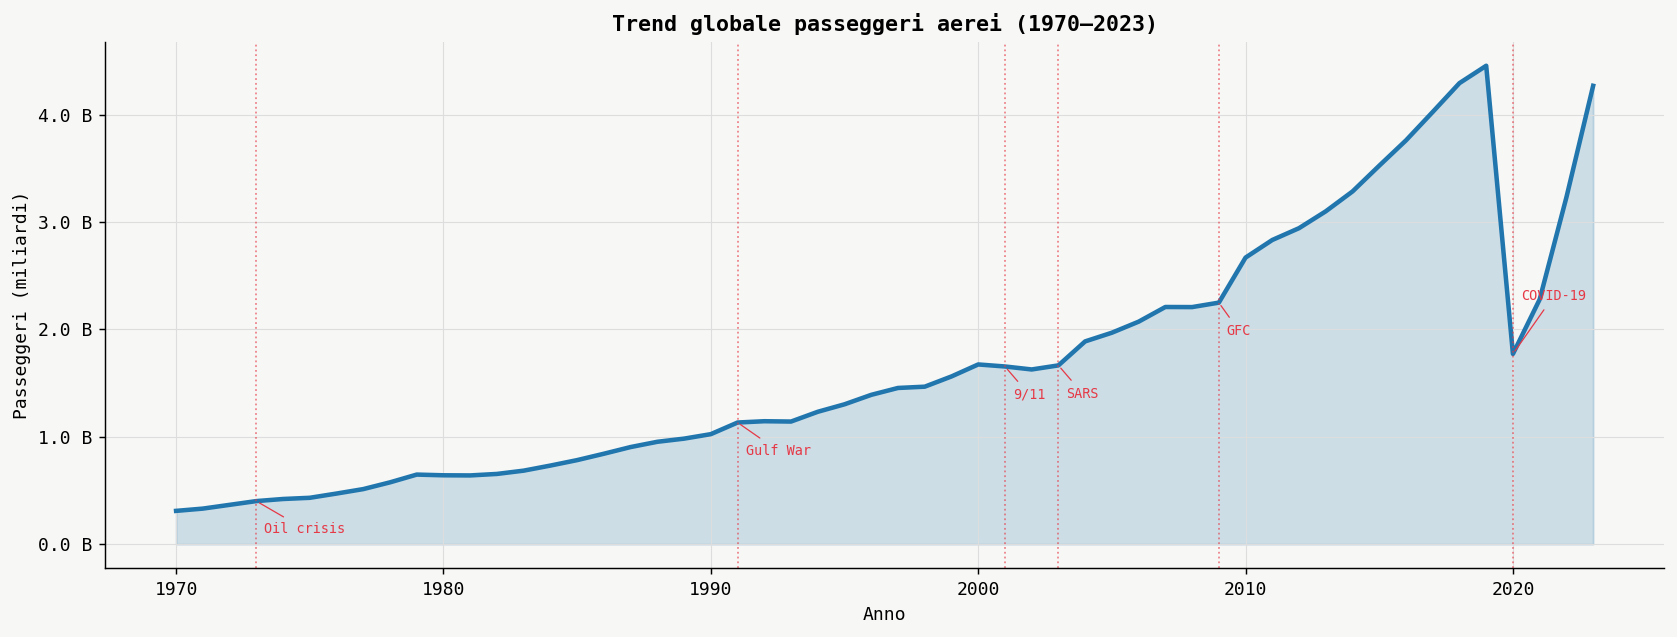

[Salvato] eda_04_world_trend.png


In [7]:

# =============================================================================
# 6. TREND GLOBALE 1970–2023
# =============================================================================
# Usa l'aggregato WLD se presente, altrimenti somma paesi
world_trend = df_long[df_long["Country Code"] == "WLD"].dropna(subset=["Passengers"])
 
if len(world_trend) < 5:
    # Fallback: somma per anno
    world_trend = (
        df_countries.groupby("Year")["Passengers"]
        .sum()
        .reset_index(name="Passengers")
    )
    world_trend = world_trend[world_trend["Year"] >= 1970]
else:
    world_trend = world_trend[world_trend["Year"] >= 1970]
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(world_trend["Year"],
                world_trend["Passengers"] / 1e9,
                alpha=0.2, color="#2176AE")
ax.plot(world_trend["Year"],
        world_trend["Passengers"] / 1e9,
        color="#2176AE", lw=2.5)
 
# Annotazioni eventi storici
events = {
    1973: ("Oil crisis", -0.3),
    1991: ("Gulf War", -0.3),
    2001: ("9/11", -0.3),
    2003: ("SARS", -0.3),
    2009: ("GFC", -0.3),
    2020: ("COVID-19", 0.5),
}
ymax = (world_trend["Passengers"] / 1e9).max()
for yr, (label, offset) in events.items():
    row = world_trend[world_trend["Year"] == yr]
    if len(row):
        y = float(row["Passengers"].values[0]) / 1e9
        ax.axvline(yr, color="#E63946", ls=":", lw=1, alpha=0.6)
        ax.annotate(label, xy=(yr, y), xytext=(yr + 0.3, y + offset),
                    fontsize=7.5, color="#E63946",
                    arrowprops=dict(arrowstyle="-", color="#E63946", lw=0.7))
 
ax.set_title("Trend globale passeggeri aerei (1970–2023)", fontweight="bold")
ax.set_xlabel("Anno")
ax.set_ylabel("Passeggeri (miliardi)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f B"))
plt.tight_layout()
#plt.savefig("eda_04_world_trend.png")
plt.show()
print("[Salvato] eda_04_world_trend.png")

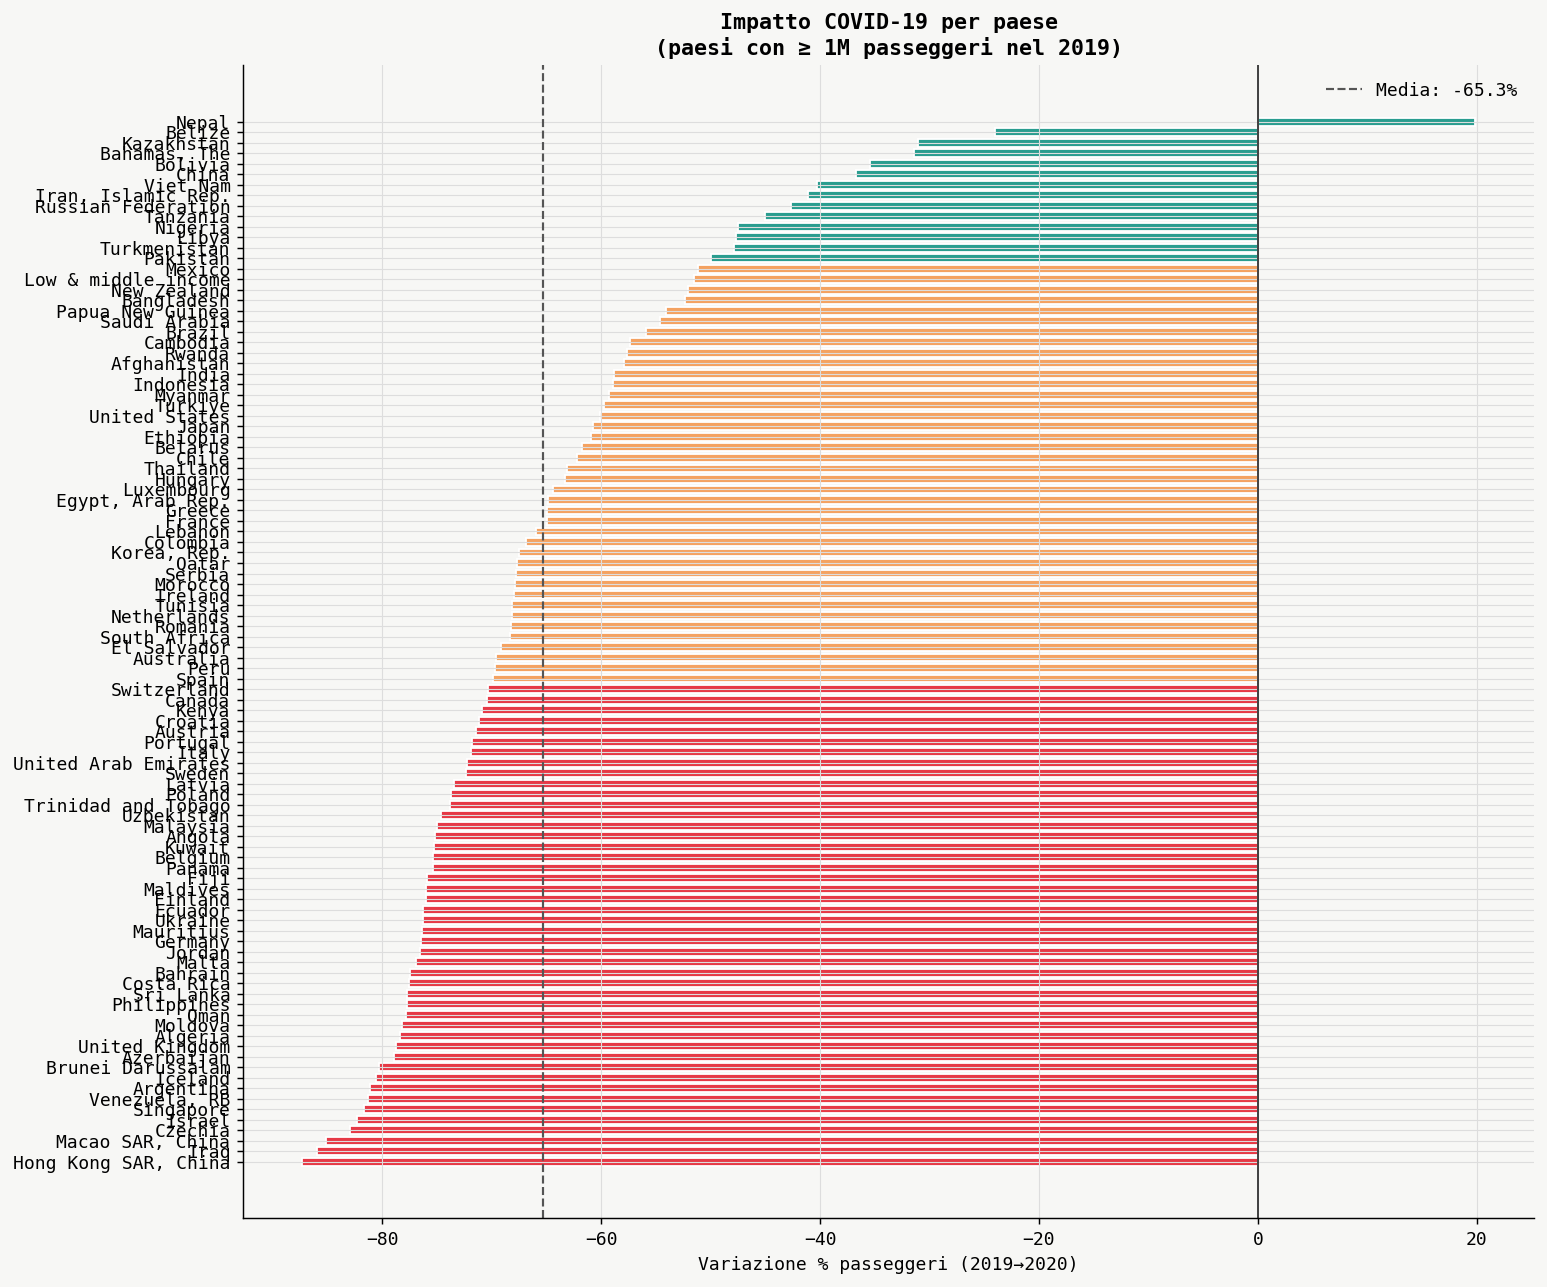

[Salvato] eda_05_covid_impact.png

  Calo medio:   -65.3%
  Calo mediano: -68.7%
  Paesi con calo > 80%: 10
  Paesi con calo < 50%: 14


In [8]:

 
# =============================================================================
# 7. IMPATTO COVID: variazione % 2019→2020 per paese
# =============================================================================
piv = df_countries[df_countries["Year"].isin([2019, 2020])].pivot_table(
    index="Country Name", columns="Year", values="Passengers"
).dropna()
 
piv["delta_pct"] = (piv[2020] - piv[2019]) / piv[2019] * 100
piv = piv.sort_values("delta_pct")
 
# Filtra paesi con almeno 1M passeggeri nel 2019
piv = piv[piv[2019] >= 1_000_000]
 
fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ["#E63946" if v < -70 else "#F4A261" if v < -50 else "#2A9D8F"
              for v in piv["delta_pct"]]
ax.barh(piv.index, piv["delta_pct"], color=colors_bar, edgecolor="white", height=0.75)
ax.axvline(0, color="#333", lw=1)
ax.axvline(piv["delta_pct"].mean(), color="#555", lw=1.2, ls="--",
           label=f"Media: {piv['delta_pct'].mean():.1f}%")
ax.set_xlabel("Variazione % passeggeri (2019→2020)")
ax.set_title("Impatto COVID-19 per paese\n(paesi con ≥ 1M passeggeri nel 2019)",
             fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_05_covid_impact.png")
plt.show()
print("[Salvato] eda_05_covid_impact.png")
 
# Stampa statistiche
print(f"\n  Calo medio:   {piv['delta_pct'].mean():.1f}%")
print(f"  Calo mediano: {piv['delta_pct'].median():.1f}%")
print(f"  Paesi con calo > 80%: {(piv['delta_pct'] < -80).sum()}")
print(f"  Paesi con calo < 50%: {(piv['delta_pct'] > -50).sum()}")

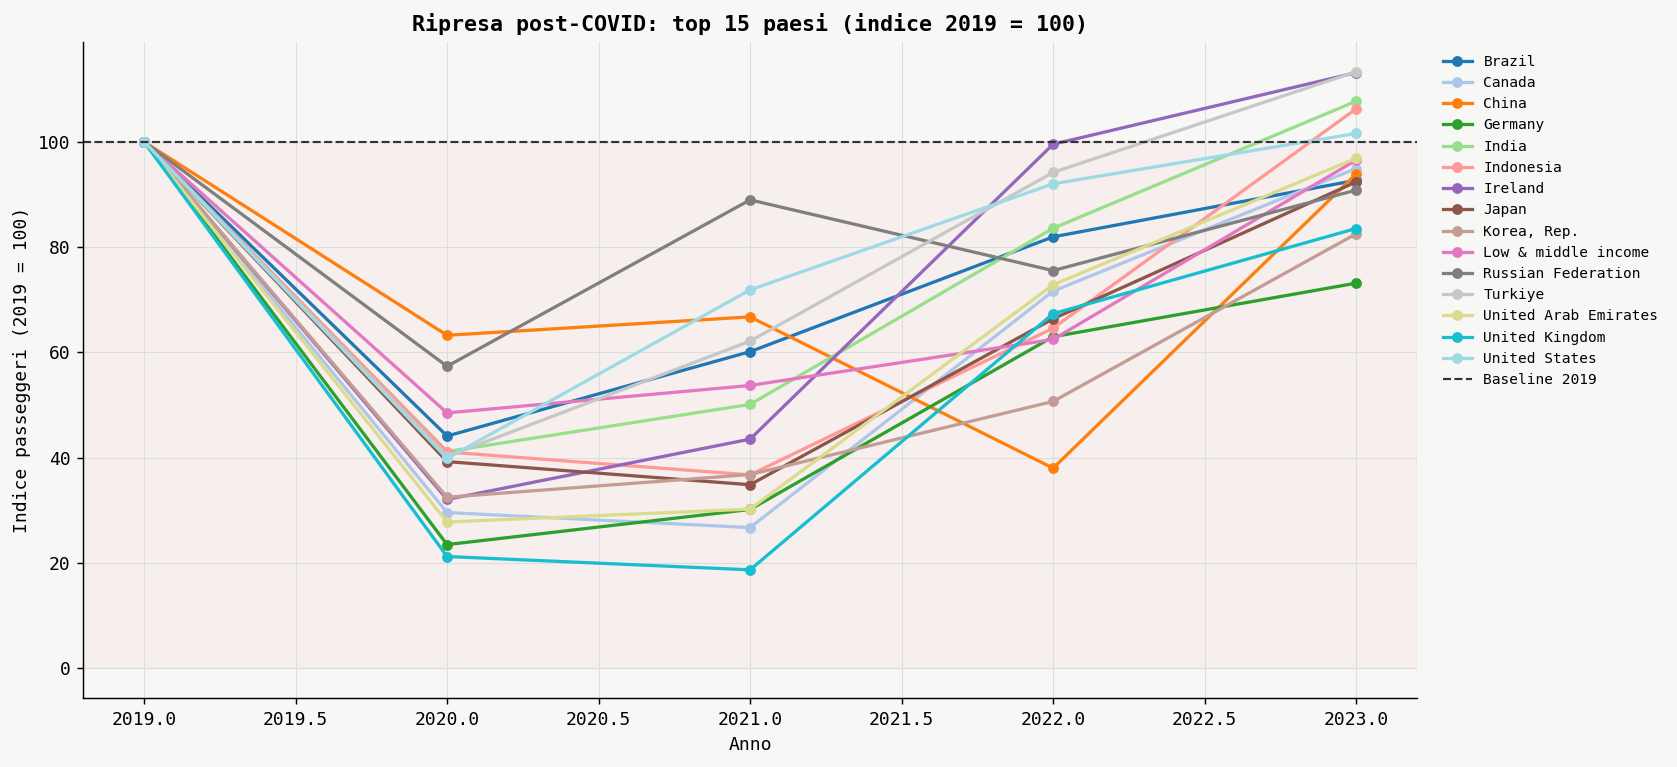

[Salvato] eda_06_recovery.png


In [9]:

 
# =============================================================================
# 8. RIPRESA POST-COVID: 2019→2021→2022→2023
# =============================================================================
recovery_years = [2019, 2020, 2021, 2022, 2023]
top_countries = (
    df_countries[df_countries["Year"] == 2019]
    .nlargest(15, "Passengers")["Country Name"].tolist()
)
 
df_rec = df_countries[
    (df_countries["Country Name"].isin(top_countries)) &
    (df_countries["Year"].isin(recovery_years))
].pivot_table(index="Country Name", columns="Year", values="Passengers")
 
# Normalizza a 2019 = 100
df_norm = df_rec.div(df_rec[2019], axis=0) * 100
 
fig, ax = plt.subplots(figsize=(13, 6))
palette = cm.get_cmap("tab20", len(df_norm))
for i, country in enumerate(df_norm.index):
    row = df_norm.loc[country].dropna()
    ax.plot(row.index, row.values, marker="o", ms=5,
            color=palette(i), lw=1.8, label=country)
 
ax.axhline(100, color="#333", lw=1.2, ls="--", label="Baseline 2019")
ax.axhspan(0, 100, alpha=0.04, color="#E63946")
ax.set_title("Ripresa post-COVID: top 15 paesi (indice 2019 = 100)",
             fontweight="bold")
ax.set_xlabel("Anno"); ax.set_ylabel("Indice passeggeri (2019 = 100)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig("eda_06_recovery.png")
plt.show()
print("[Salvato] eda_06_recovery.png")

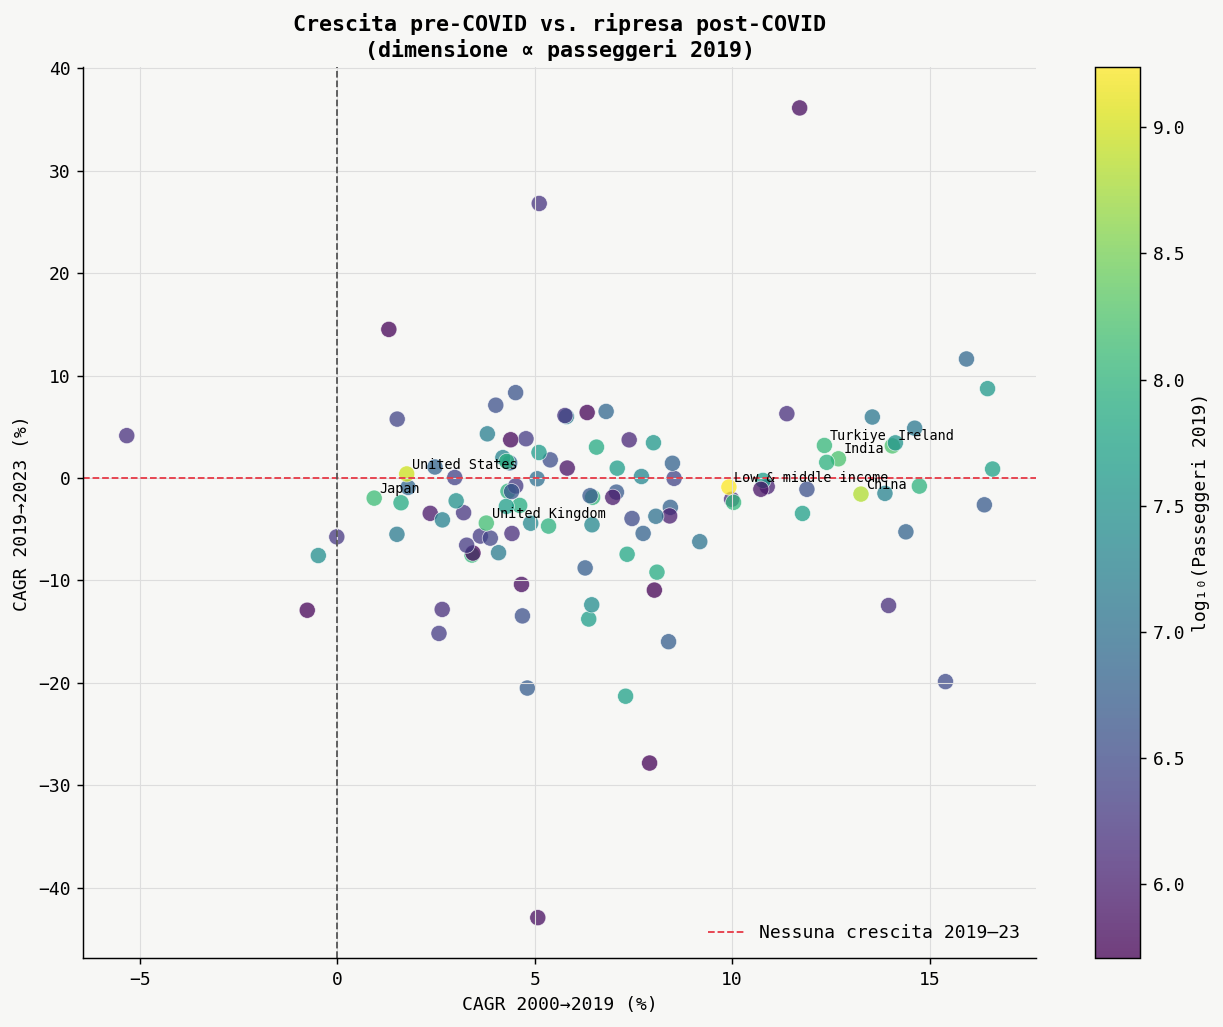

[Salvato] eda_07_cagr_scatter.png


In [10]:
 
# =============================================================================
# 9. CRESCITA A LUNGO TERMINE: CAGR 2000→2019 vs 2019→2023
# =============================================================================
def cagr(start, end, n):
    if start is None or end is None or start <= 0 or end <= 0:
        return np.nan
    return ((end / start) ** (1 / n) - 1) * 100
 
df_cagr_raw = df_countries[df_countries["Year"].isin([2000, 2019, 2023])].pivot_table(
    index="Country Name", columns="Year", values="Passengers"
).dropna()
 
df_cagr_raw["cagr_00_19"] = df_cagr_raw.apply(
    lambda r: cagr(r[2000], r[2019], 19), axis=1)
df_cagr_raw["cagr_19_23"] = df_cagr_raw.apply(
    lambda r: cagr(r[2019], r[2023], 4), axis=1)
 
# Solo paesi con almeno 500k pax 2019
df_cagr_raw = df_cagr_raw[df_cagr_raw[2019] >= 500_000].dropna()
 
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df_cagr_raw["cagr_00_19"],
    df_cagr_raw["cagr_19_23"],
    c=np.log10(df_cagr_raw[2019]),
    cmap="viridis", s=80, alpha=0.75, edgecolors="white", lw=0.4
)
cbar = plt.colorbar(sc, ax=ax, label="log₁₀(Passeggeri 2019)")
ax.axhline(0, color="#E63946", ls="--", lw=1, label="Nessuna crescita 2019–23")
ax.axvline(0, color="#555", ls="--", lw=1)
 
# Etichette top paesi
highlight = df_cagr_raw.nlargest(8, 2019).index.tolist()
for c in highlight:
    ax.annotate(c,
                xy=(df_cagr_raw.loc[c, "cagr_00_19"],
                    df_cagr_raw.loc[c, "cagr_19_23"]),
                fontsize=7.5, ha="left",
                xytext=(3, 3), textcoords="offset points")
 
ax.set_xlabel("CAGR 2000→2019 (%)")
ax.set_ylabel("CAGR 2019→2023 (%)")
ax.set_title("Crescita pre-COVID vs. ripresa post-COVID\n(dimensione ∝ passeggeri 2019)",
             fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("eda_07_cagr_scatter.png")
plt.show()
print("[Salvato] eda_07_cagr_scatter.png")


Paesi con copertura completa 1990–2023: 98


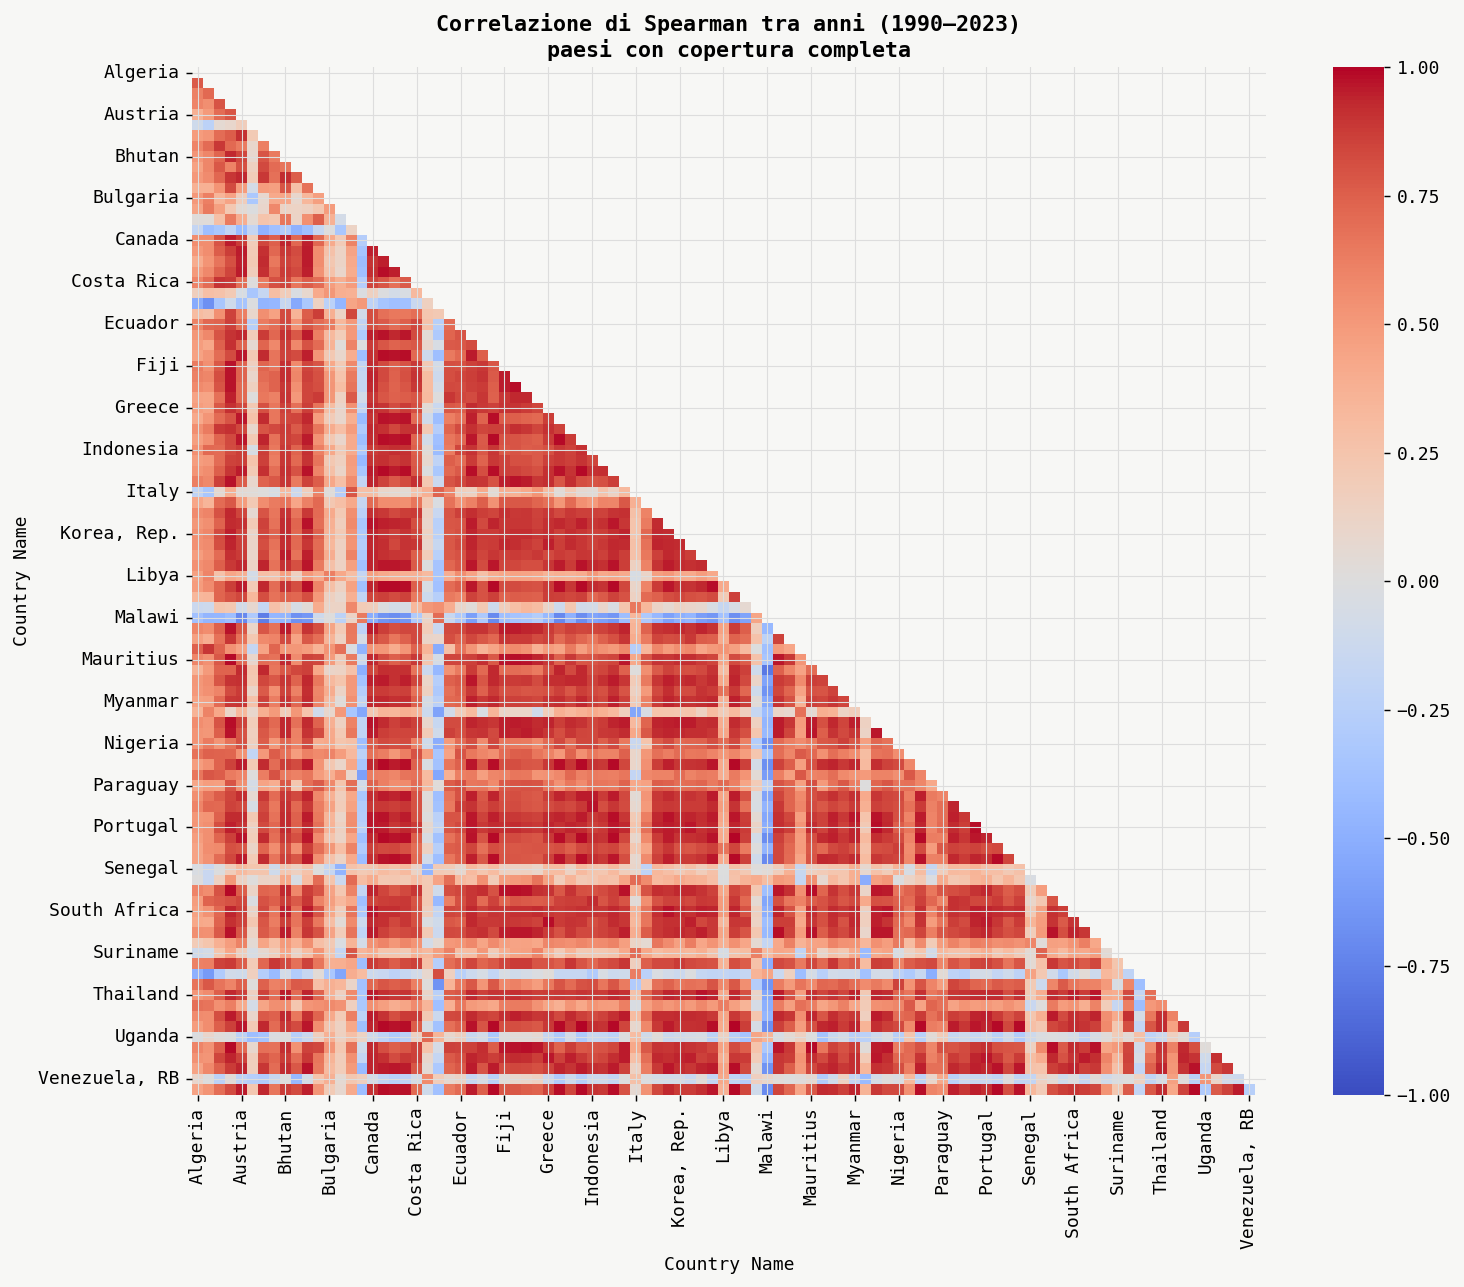

[Salvato] eda_08_corr_heatmap.png


In [11]:
# =============================================================================
# 10. HEATMAP CORRELAZIONE anni (campione paesi con copertura completa)
# =============================================================================
years_subset = list(range(1990, 2024))
df_wide = df_countries[df_countries["Year"].isin(years_subset)].pivot_table(
    index="Country Name", columns="Year", values="Passengers"
)
df_wide_clean = df_wide.dropna(axis=0)  # solo paesi con tutti gli anni
 
print(f"\nPaesi con copertura completa 1990–2023: {len(df_wide_clean)}")
 
corr = df_wide_clean.T.corr(method="spearman")   # correlazione tra anni
 
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0, ax=ax,
            xticklabels=4, yticklabels=4)
ax.set_title("Correlazione di Spearman tra anni (1990–2023)\npaesi con copertura completa",
             fontweight="bold")
plt.tight_layout()
plt.savefig("eda_08_corr_heatmap.png")
plt.show()
print("[Salvato] eda_08_corr_heatmap.png")

In [12]:
# =============================================================================
# 11. RIEPILOGO TESTUALE
# =============================================================================
print("\n" + "="*60)
print("RIEPILOGO EDA — df1.csv")
print("="*60)
 
last_yr = df_countries[df_countries["Year"] == 2023].dropna(subset=["Passengers"])
top5 = last_yr.nlargest(5, "Passengers")[["Country Name","Passengers"]]
print("\nTop 5 paesi per passeggeri (2023):")
for _, r in top5.iterrows():
    print(f"  {r['Country Name']:<30} {r['Passengers']/1e9:.2f} B")
 
piv2 = df_countries[df_countries["Year"].isin([2019, 2022, 2023])].pivot_table(
    index="Country Name", columns="Year", values="Passengers"
).dropna()
piv2["rec_23"] = piv2[2023] / piv2[2019] * 100
fully = (piv2["rec_23"] >= 100).sum()
print(f"\nPaesi tornati al 100% del 2019 nel 2023: {fully} / {len(piv2)}")
print(f"Media ripresa 2023 vs 2019: {piv2['rec_23'].mean():.1f}%")
 


RIEPILOGO EDA — df1.csv

Top 5 paesi per passeggeri (2023):
  Low & middle income            1.66 B
  United States                  0.94 B
  China                          0.62 B
  Ireland                        0.19 B
  India                          0.18 B

Paesi tornati al 100% del 2019 nel 2023: 53 / 143
Media ripresa 2023 vs 2019: 141.6%
